<a href="https://colab.research.google.com/github/EsraaMahmoud09/Customer-Churn-Prediction-using-Machine-Learning-Pipeline-Scaling-GridSearchCV-Model-Evaluation-/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Accuracy before EDA**

# Load Libararies

In [14]:
import os
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score,accuracy_score,mean_squared_error
from sklearn.linear_model import Ridge, LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [15]:
RANDOM_STATE = 42
np.set_printoptions(suppress=True)

# Read Data
df = pd.read_csv('/content/Churn.csv')

df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})  ## Converter
df = pd.get_dummies(df, drop_first=True)  ## Encoding

X = df.drop('Churn', axis=1)
y = df['Churn']

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Scaling is important for KNN due to distance computations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict acc
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(f"(Baseline Accuracy): {accuracy * 100:.2f}% , (R-Square): {score}")

(Baseline Accuracy): 80.70% , (R-Square): 0.009925340360123047


# **Accuracy After EDA**

In [16]:
# You are working as a Data Analyst in a telecommunications company. Your goal is to analyze customer data to
# understand the reasons behind customer churn and present data-driven insights
# and recommendations to stakeholders.
# 1. Data Cleaning 2. Exploratory Data Analysis (EDA):
# Explore the dataset:
# o Total number of customers
# o Churn rate
# o Distribution of key variables
# • Use appropriate visualizations (bar charts, box plots, histograms)

In [17]:
df = pd.read_csv('/content/Churn.csv')

In [18]:


file_path = '/content/Churn.csv'

if os.path.exists(file_path):
    print(f"File '{os.path.basename(file_path)}' found at '{file_path}'.")
else:
    print(f"File '{os.path.basename(file_path)}' not found at '{file_path}'.")
    print("Please upload the file to your Colab environment or ensure the path is correct.")
    print("You can upload files using the folder icon on the left sidebar.")

File 'Churn.csv' found at '/content/Churn.csv'.


In [19]:
pd.set_option("display.max_columns", None)

In [20]:
df.shape

(7043, 21)

In [21]:
df.head ()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print(df['MultipleLines'].unique())

['No' 'Yes']


In [23]:
columns_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in columns_to_fix:
  df[col] = df[col].replace('No internet service', 'No')


Some columns contained inconsistent values like "No phone service" and "No internet service", which represent the same meaning as "No".
These values were standardized by replacing them with "No" to ensure consistency across the dataset.
This improves data quality, reduces category redundancy, and makes analysis and visualization more accurate.

In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


**TotalCharges** contains missing values (11 records) and may have data type issues.

**SeniorCitizen** is encoded as numeric (0/1) but should be treated as a categorical variable.

Some features like **TotalCharges** show right skewness and high variability, indicating diverse customer behavior.

In [25]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [26]:
# Fill with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [27]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365,5174


**customerID** is a unique identifier with no analytical value, so it was removed from the dataset.

In [28]:
df = df.drop('customerID', axis=1)

In [29]:
print(df.duplicated().sum())

22


In [30]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


# EDA



In [31]:
# 3. Business Questions (Answer All): 1. What are the main factors affecting customer churn?
# Problem: The company is losing customers but does not clearly know why. Hint:
# •Compare Churn with:
# o Contract
# o Monthly Charges
# o Tenure
# o Internet Service
# 2. Does contract type impact churn rate? Yes
# 3. Do customers with higher monthly charges churn more? Yes
# 4. How does tenure affect churn probability?

In [32]:
# Get total number of customers in the dataset
total_number_of_customers = len(df)

# Count customers who churned (Churn = Yes)
churn_customers = len(df[df['Churn'] == 'Yes'])

# Calculate churn rate as a percentage
churn_rate = (churn_customers / total_number_of_customers) * 100

# Print the churn rate with formatting
print(f"Churn Rate : {churn_rate:.2f}%")

Churn Rate : 26.45%


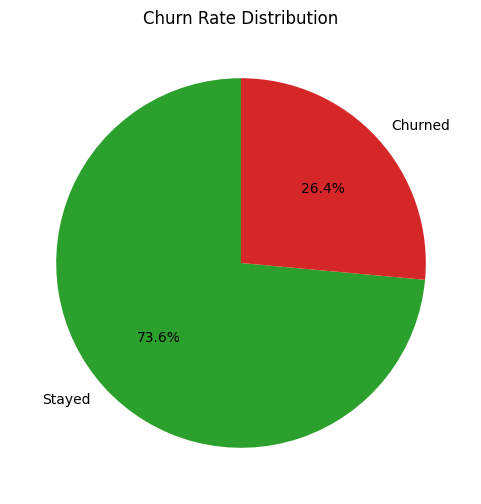

In [33]:
# Data for pie chart
labels = ['Stayed', 'Churned']

# Calculate not_churn_customers
not_churn_customers = total_number_of_customers - churn_customers

sizes = [not_churn_customers, churn_customers]
colors = ['#2ca02c', '#d62728']  # green = stayed, red = churned

# Plot
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Churn Rate Distribution')
plt.show()

**Insights**
Retention Strength: A 73.5% retention rate suggests a solid foundation, but there is significant room for improvement.

The "Churn" Warning: A churn rate of over 25% is often considered high in many industries (like SaaS or telecommunications). It suggests that one out of every four customers is leaving, which could impact long-term revenue growth.

Actionable Outlook: To improve these numbers, the business should investigate why that 26.5% is leaving—whether it’s due to pricing, customer service issues, or a lack of perceived value—to prevent the green "Stayed" slice from shrinking further.


CATEGORICAL FEATURES SUMMARY

Feature: gender
        Count  Percentage
gender                   
Male     3541       50.43
Female   3480       49.57
--------------------------------------------------


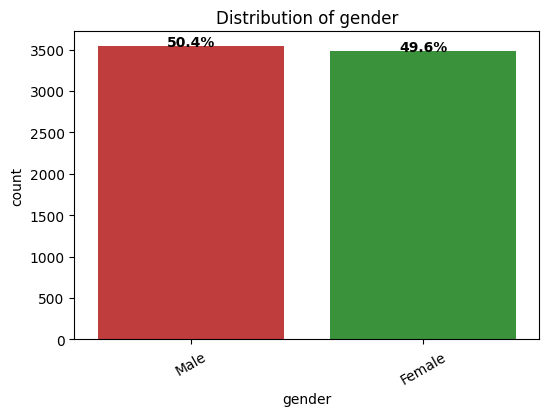


Feature: Partner
         Count  Percentage
Partner                   
No        3619       51.55
Yes       3402       48.45
--------------------------------------------------


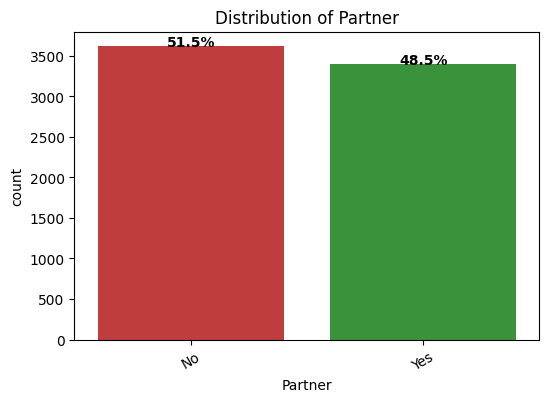


Feature: Dependents
            Count  Percentage
Dependents                   
No           4911       69.95
Yes          2110       30.05
--------------------------------------------------


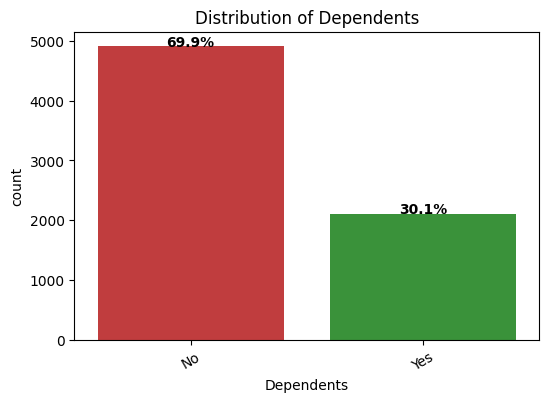


Feature: PhoneService
              Count  Percentage
PhoneService                   
Yes            6339       90.29
No              682        9.71
--------------------------------------------------


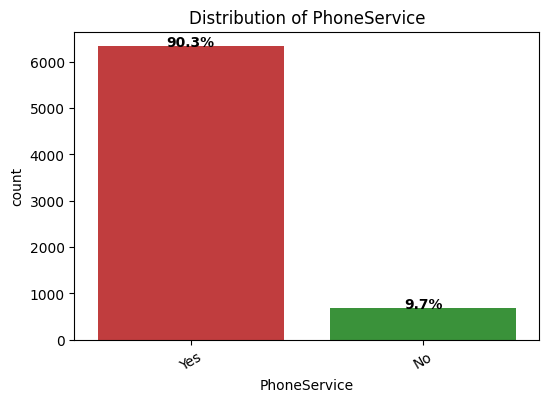


Feature: MultipleLines
               Count  Percentage
MultipleLines                   
No              4050       57.68
Yes             2971       42.32
--------------------------------------------------


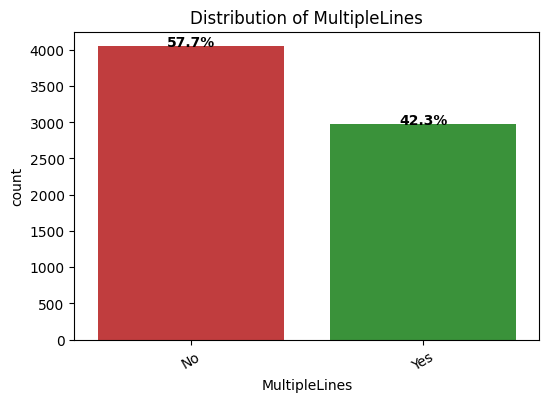


Feature: InternetService
                 Count  Percentage
InternetService                   
Fiber optic       3090       44.01
DSL               2419       34.45
No                1512       21.54
--------------------------------------------------


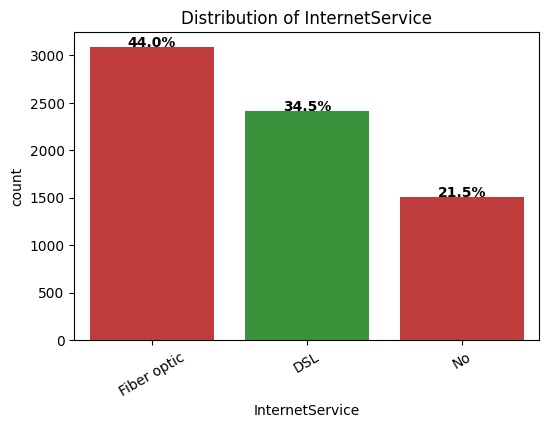


Feature: OnlineSecurity
                Count  Percentage
OnlineSecurity                   
No               5002       71.24
Yes              2019       28.76
--------------------------------------------------


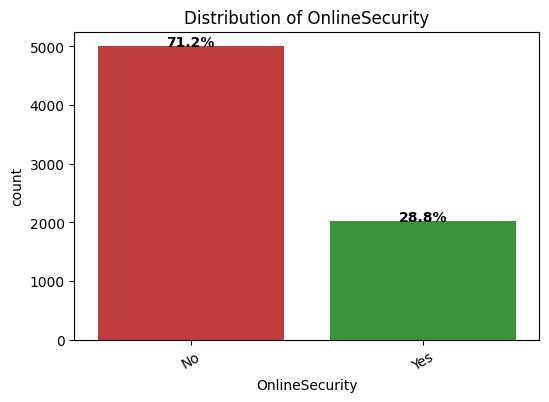


Feature: OnlineBackup
              Count  Percentage
OnlineBackup                   
No             4592        65.4
Yes            2429        34.6
--------------------------------------------------


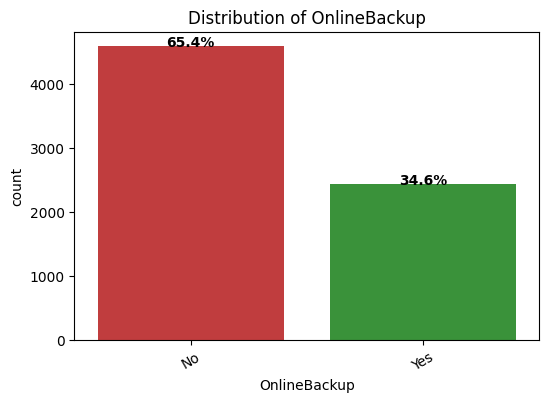


Feature: DeviceProtection
                  Count  Percentage
DeviceProtection                   
No                 4599        65.5
Yes                2422        34.5
--------------------------------------------------


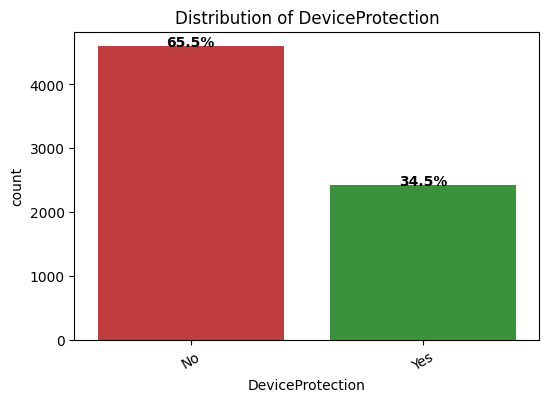


Feature: TechSupport
             Count  Percentage
TechSupport                   
No            4977       70.89
Yes           2044       29.11
--------------------------------------------------


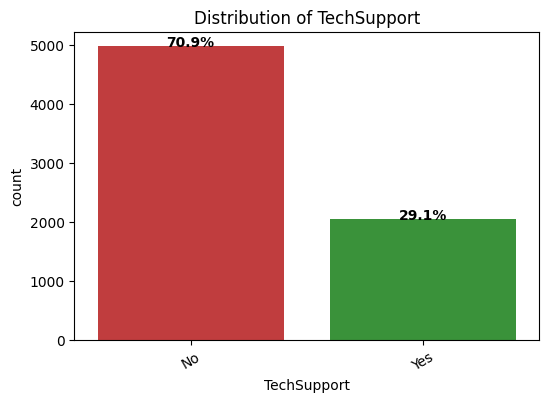


Feature: StreamingTV
             Count  Percentage
StreamingTV                   
No            4314       61.44
Yes           2707       38.56
--------------------------------------------------


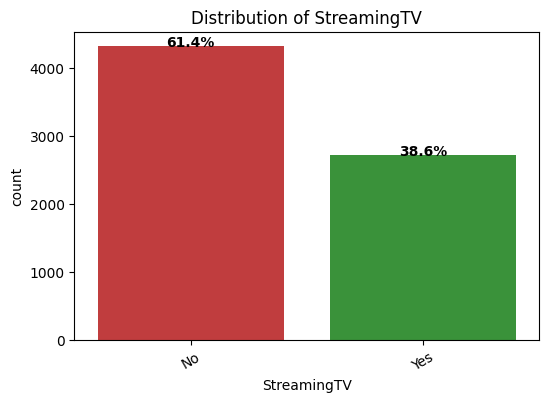


Feature: StreamingMovies
                 Count  Percentage
StreamingMovies                   
No                4289       61.09
Yes               2732       38.91
--------------------------------------------------


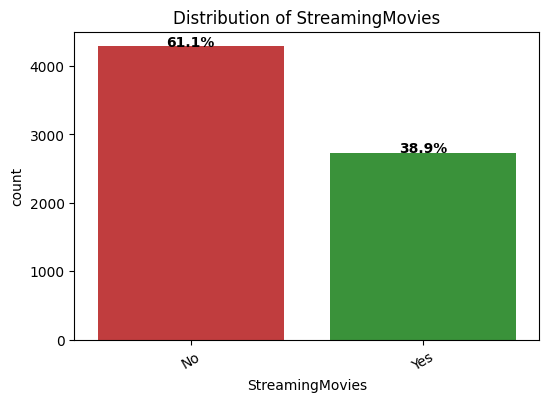


Feature: Contract
                Count  Percentage
Contract                         
Month-to-month   3853       54.88
Two year         1695       24.14
One year         1473       20.98
--------------------------------------------------


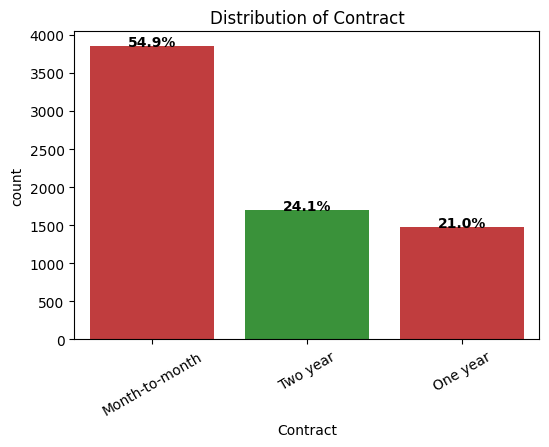


Feature: PaperlessBilling
                  Count  Percentage
PaperlessBilling                   
Yes                4161       59.27
No                 2860       40.73
--------------------------------------------------


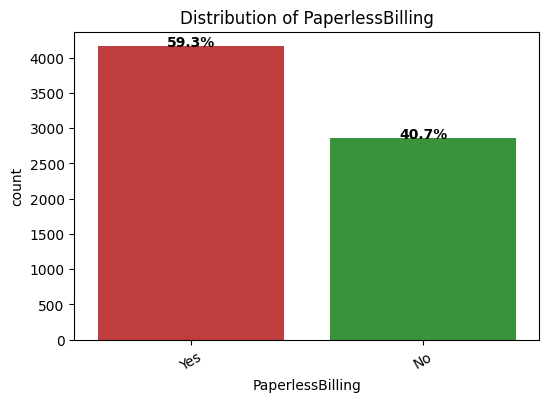


Feature: PaymentMethod
                           Count  Percentage
PaymentMethod                               
Electronic check            2359       33.60
Mailed check                1596       22.73
Bank transfer (automatic)   1544       21.99
Credit card (automatic)     1522       21.68
--------------------------------------------------


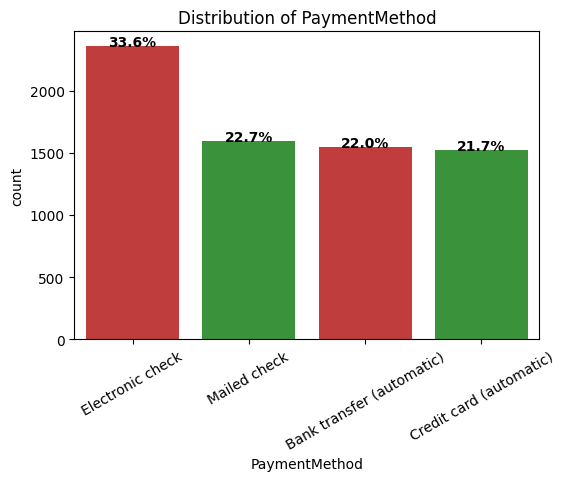


Feature: Churn
       Count  Percentage
Churn                   
No      5164       73.55
Yes     1857       26.45
--------------------------------------------------


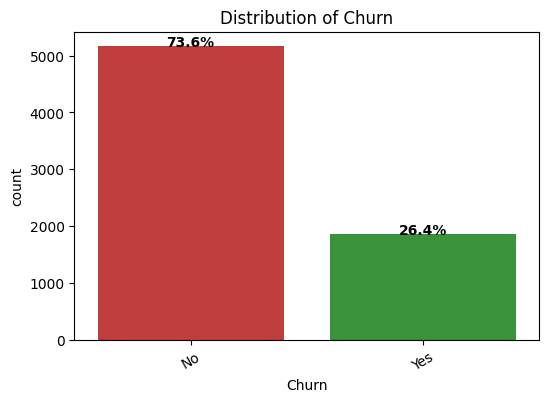

In [34]:
# Univariate Categorical Analysis
cat_features = df.select_dtypes(include='object').columns

print("\n" + "="*50)
print("CATEGORICAL FEATURES SUMMARY")
print("="*50)

for col in cat_features:
    print("\nFeature:", col)

    # Value counts + percentages
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    print(pd.concat([value_counts, percentages.round(2)], axis=1, keys=['Count', 'Percentage']))
    print("-"*50)

    # Plot
    plt.figure(figsize=(6,4))
    ax = sns.countplot(
        data=df,
        x=col,
        order=value_counts.index,
        palette=['#d62728', '#2ca02c']  # red & green
    )

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=30)

    # Add percentage labels
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        percentage = (height / total) * 100
        ax.text(
            p.get_x() + p.get_width()/2,
            height + 0.5,
            f'{percentage:.1f}%',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    plt.show()

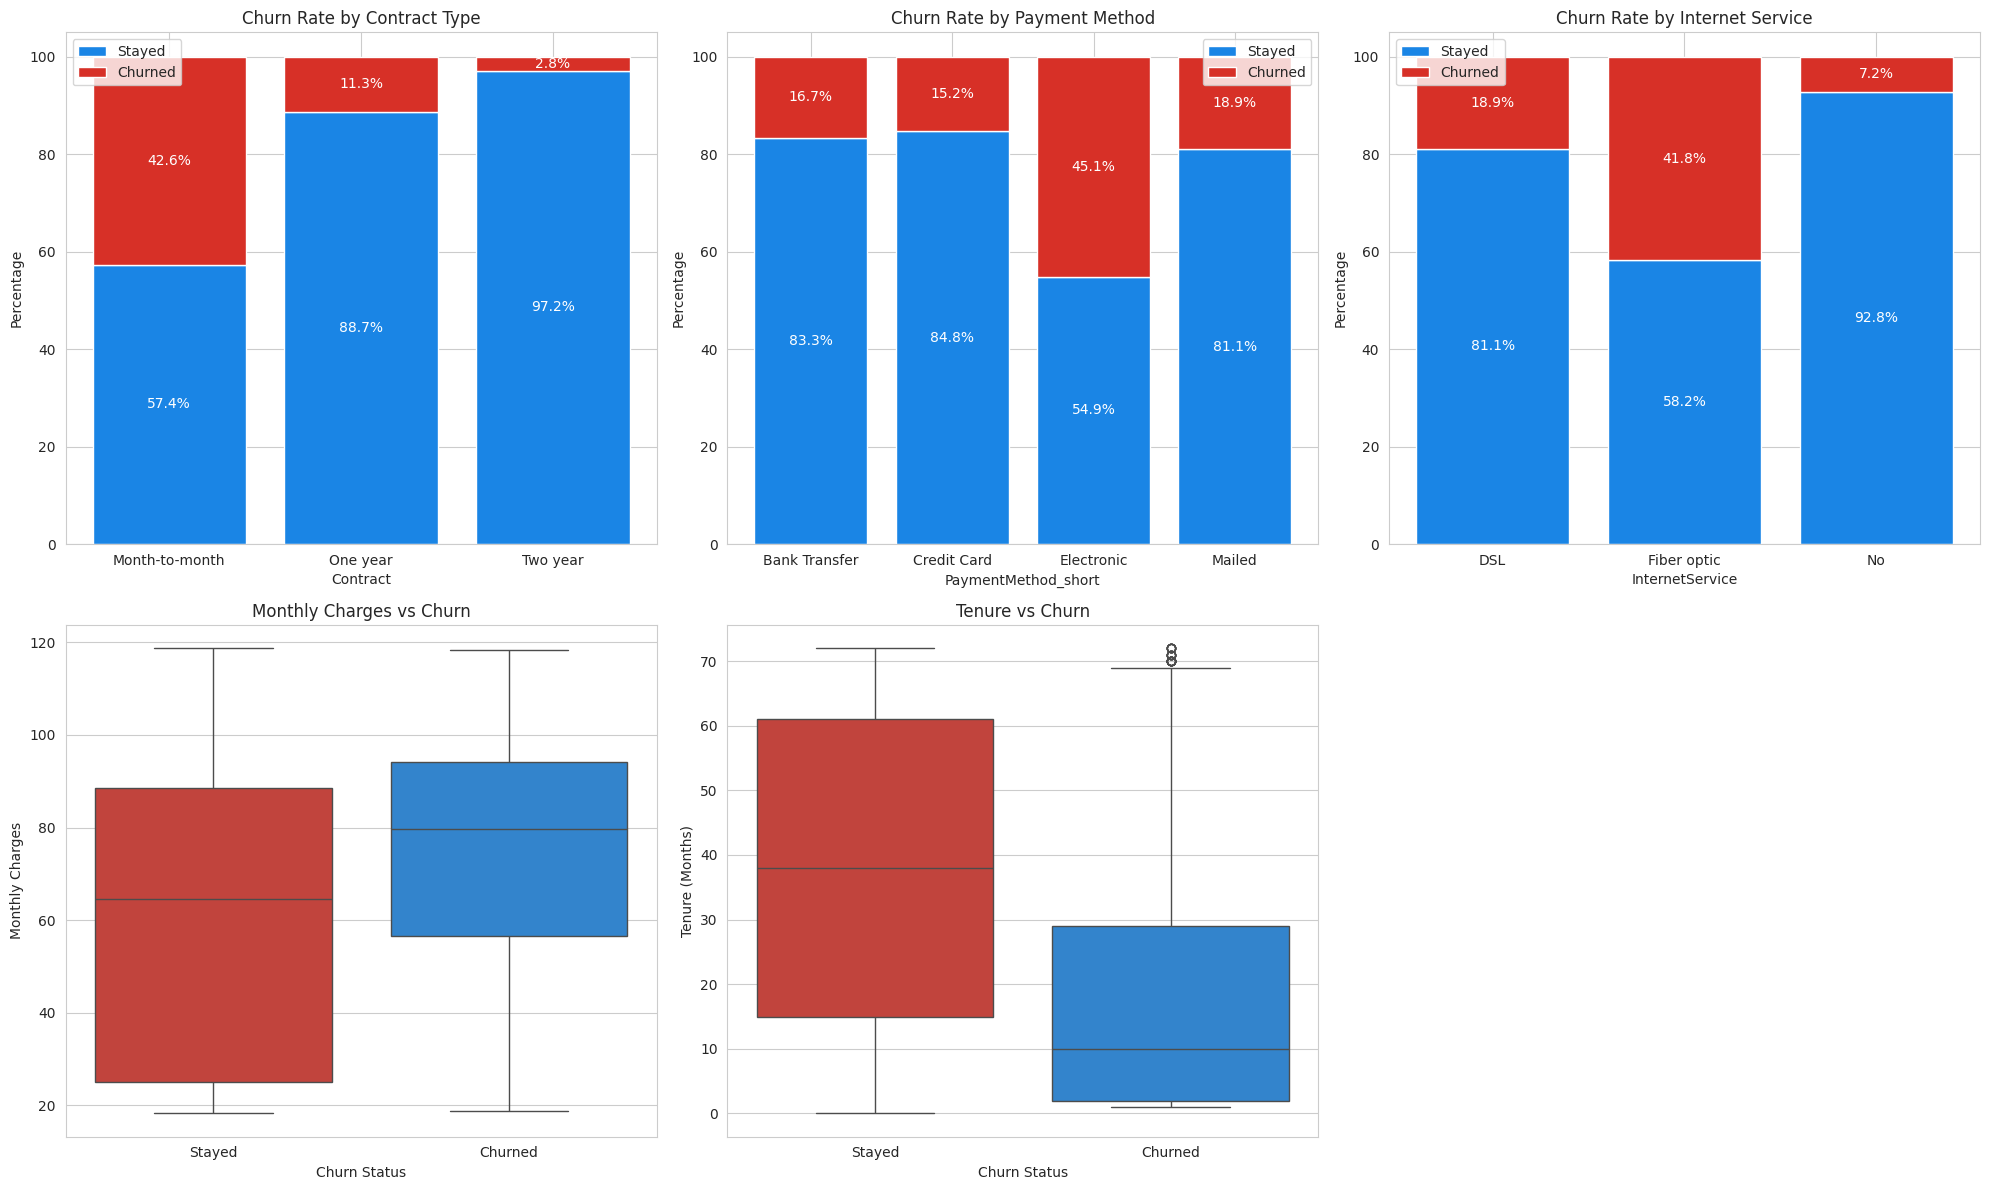

In [35]:
sns.set_style("whitegrid")

# Ensure 'Churn' column is numerical (0 for No, 1 for Yes)
# This check handles cases where Churn might already be numerical or was previously 'Yes'/'No'
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Create Churn label from numerical Churn
df['Churn_label'] = df['Churn'].map({0:'Stayed', 1:'Churned'})
df['PaymentMethod_short'] = df['PaymentMethod'].map({
    'Electronic check':'Electronic',
    'Mailed check':'Mailed',
    'Bank transfer (automatic)':'Bank Transfer',
    'Credit card (automatic)':'Credit Card'
})

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# =========================
# Helper function to plot stacked bar with percentages
# =========================
def plot_stacked_percentage(ax, feature, title):
    ct = pd.crosstab(df[feature], df['Churn_label'], normalize='index') * 100
    stayed = ct['Stayed']
    churned = ct['Churned']

    ax.bar(ct.index, stayed, color='#1a85e5', label='Stayed')
    ax.bar(ct.index, churned, bottom=stayed, color='#d73027', label='Churned')

    # Add percentages
    for i, (s, c) in enumerate(zip(stayed, churned)):
        ax.text(i, s/2, f'{s:.1f}%', ha='center', va='center', fontsize=10, color='white')
        ax.text(i, s + c/2, f'{c:.1f}%', ha='center', va='center', fontsize=10, color='white')

    ax.set_title(title)
    ax.set_ylabel("Percentage")
    ax.set_xlabel(feature)
    ax.legend()

# Contract
plot_stacked_percentage(axes[0], 'Contract', 'Churn Rate by Contract Type')

# Payment Method
plot_stacked_percentage(axes[1], 'PaymentMethod_short', 'Churn Rate by Payment Method')

# Internet Service
plot_stacked_percentage(axes[2], 'InternetService', 'Churn Rate by Internet Service')

# Boxplot Monthly Charges
sns.boxplot(x='Churn_label', y='MonthlyCharges', data=df, ax=axes[3], palette=['#d73027','#1a85e5'])
axes[3].set_title("Monthly Charges vs Churn")
axes[3].set_xlabel("Churn Status")
axes[3].set_ylabel("Monthly Charges")

# Boxplot Tenure
sns.boxplot(x='Churn_label', y='tenure', data=df, ax=axes[4], palette=['#d73027','#1a85e5'])
axes[4].set_title("Tenure vs Churn")
axes[4].set_xlabel("Churn Status")
axes[4].set_ylabel("Tenure (Months)")

# Hide 6th empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

**The Critical Period**: Churn is highest in the first 12 months. The first 30 days are the most unstable for any new customer.

**Contract Risk**: Month-to-month users are the most likely to leave. Annual contracts act as a "shield" against churn.

**The Fiber Paradox**: Fiber Optic customers churn more than DSL users, likely due to higher price sensitivity or service instability.

**Missing "Anchors"**: Customers without Tech Support or Online Security leave much faster. These services create "product stickiness."

**Payment Friction**: Electronic Check payments correlate with higher churn. Auto-pay (Credit Card/Bank) leads to better retention.

**Senior Risk**: Senior Citizens have a churn rate of 41.6%, requiring simplified and discounted plans.

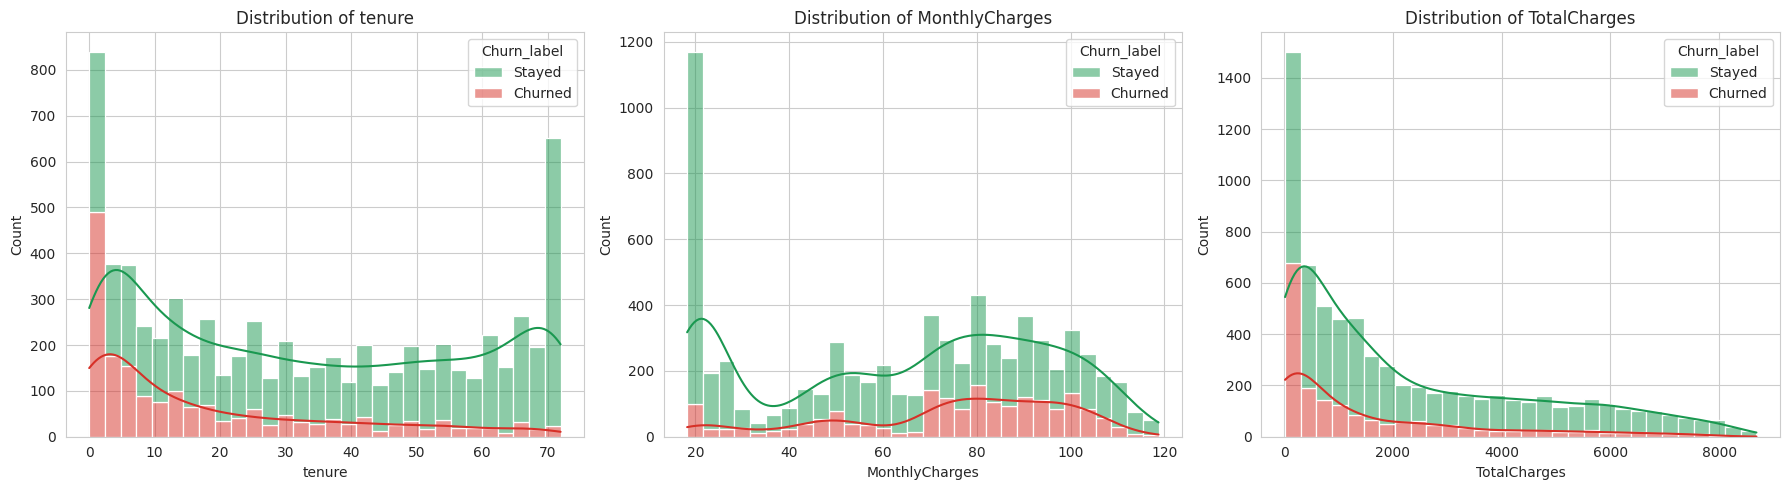

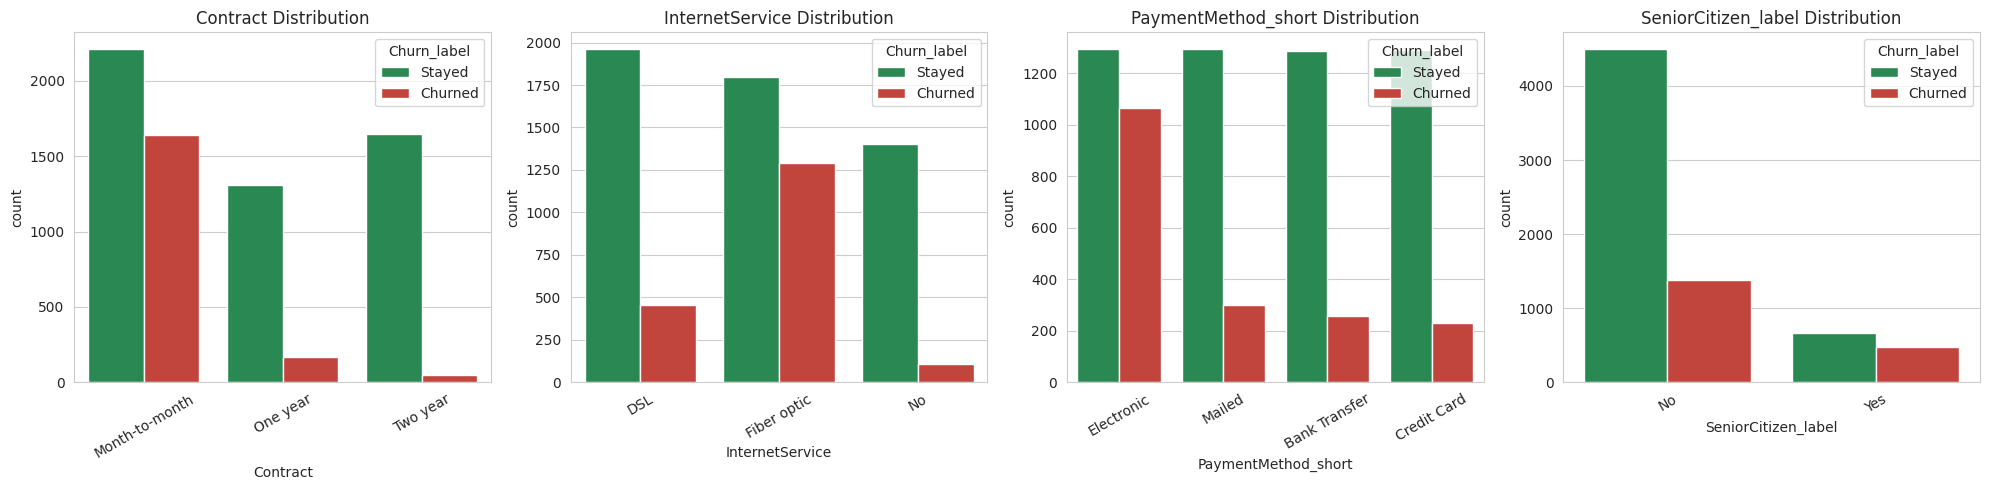

SeniorCitizen_label
No     23.503401
Yes    41.630149
Name: Churn, dtype: float64


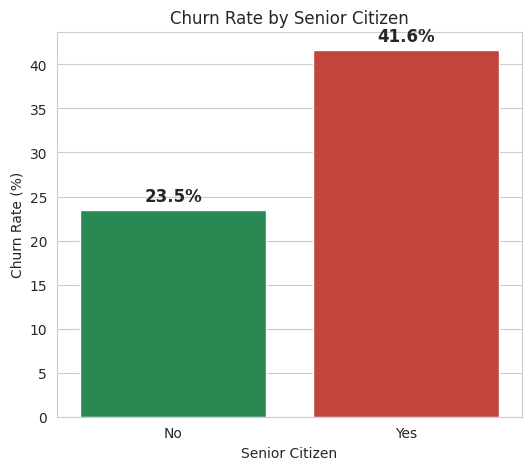

In [36]:
# Convert Churn to numerical ONLY IF it's still object type (contains strings 'No'/'Yes')
# This ensures robustness against repeated execution or prior conversions
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

# Add label column for visualization (now based on the numerical Churn 0/1)
df['Churn_label'] = df['Churn'].map({0:'Stayed', 1:'Churned'})

# =========================
# 4. Shorten PaymentMethod names
# =========================
df['PaymentMethod_short'] = df['PaymentMethod'].map({
    'Electronic check':'Electronic',
    'Mailed check':'Mailed',
    'Bank transfer (automatic)':'Bank Transfer',
    'Credit card (automatic)':'Credit Card'
})

# =========================
# Add label column for SeniorCitizen
# =========================
df['SeniorCitizen_label'] = df['SeniorCitizen'].map({
    0: 'No',
    1: 'Yes'
})

# =========================
# 5. Numerical Distribution
# =========================
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(num_features):
    sns.histplot(
        data=df,
        x=col,
        hue='Churn_label',
        bins=30,
        palette=['#1a9850', '#d73027'],
        alpha=0.5,
        multiple='stack',  # stacked bars
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


# =========================
# 6. Categorical Distribution
# =========================
cat_features = ['Contract', 'InternetService', 'PaymentMethod_short', 'SeniorCitizen_label']

fig, axes = plt.subplots(1, len(cat_features), figsize=(20,5)) # Changed 3 to len(cat_features) and adjusted figsize

for i, col in enumerate(cat_features):

    sns.countplot(
        data=df,
        x=col,
        hue='Churn_label',
        palette=['#1a9850', '#d73027'],
        ax=axes[i]
    )

    axes[i].set_title(f'{col} Distribution')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


# =========================
# 7. Churn Rate by Senior Citizen
# =========================

churn_rate_senior = df.groupby('SeniorCitizen_label')['Churn'].mean() * 100

print(churn_rate_senior)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=churn_rate_senior.index,
    y=churn_rate_senior.values,
    palette=['#1a9850', '#d73027']
)

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

# =========================
# Add percentage labels on bars
# =========================
for i, value in enumerate(churn_rate_senior.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.show()

**Insights**:

The "**New Customer**" Risk: The Tenure chart shows a massive spike in churn during the first few months. If a customer survives the first year, they are much more likely to stay long-term.

**Contract Type is Critical**: Customers on Month-to-month contracts have a significantly higher churn rate compared to those on one or two-year contracts. Loyalty is tied to commitment.

**Fiber Optic Issues**: Paradoxically, Fiber optic users churn more than DSL users. This might suggest issues with pricing or service stability for high-speed internet.

**Payment Friction**: Customers using Electronic Checks churn at a much higher rate than those using automated methods like Bank Transfer or Credit Cards.

**Senior Citizen Vulnerability**: The bottom chart shows that Senior Citizens have a much higher churn rate (41.6%) compared to non-seniors (23.5%). This group might find the service too expensive or difficult to use.

  tenure_group  Churn_numeric
0         0-12      47.607989
1        13-24      28.710938
2        25-36      21.634615
3        37-48      19.028871
4        49-60      14.423077
5          61+       6.609808


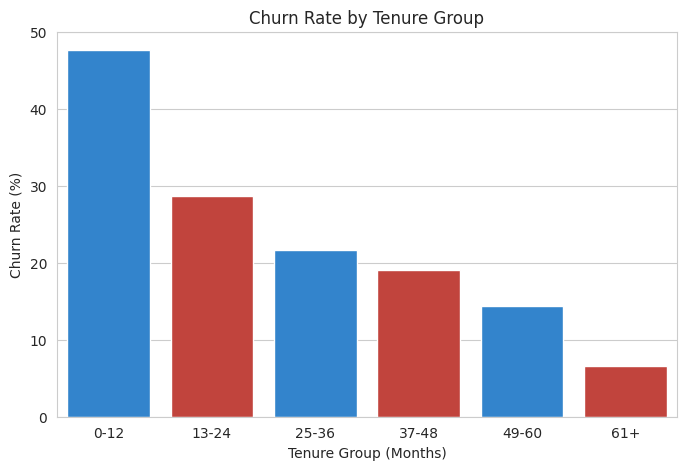

In [37]:
df['Churn_numeric'] = df['Churn']

bins = [0, 12, 24, 36, 48, 60, df['tenure'].max()]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61+']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

tenure_churn = df.groupby('tenure_group')['Churn_numeric'].mean().reset_index()
tenure_churn['Churn_numeric'] = tenure_churn['Churn_numeric'] * 100

tenure_churn['tenure_group'] = pd.Categorical(tenure_churn['tenure_group'], categories=labels, ordered=True)
tenure_churn = tenure_churn.sort_values('tenure_group')

print(tenure_churn)

plt.figure(figsize=(8,5))
sns.barplot(x='tenure_group', y='Churn_numeric', data=tenure_churn, palette=['#1a85e5','#d73027'])
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Rate (%)')
plt.ylim(0,50)
plt.show()

**Insights**:

The Critical First Year: The 0-12 months group has a staggering churn rate of nearly 48%. Almost half of your new customers leave within the first year. This suggests a major issue with the "onboarding" phase or the initial value proposition.

Loyalty Maturity: Once a customer crosses the 5-year mark (61+ months), the churn rate drops to its lowest point (below 10%). These are your "brand advocates" or highly stable revenue sources.

The "Cliff" Effect: There is a massive drop in churn between the first group (0-12) and the second group (13-24). This indicates that if you can keep a customer for just 13 months, their chance of staying jumps up by nearly 20%.

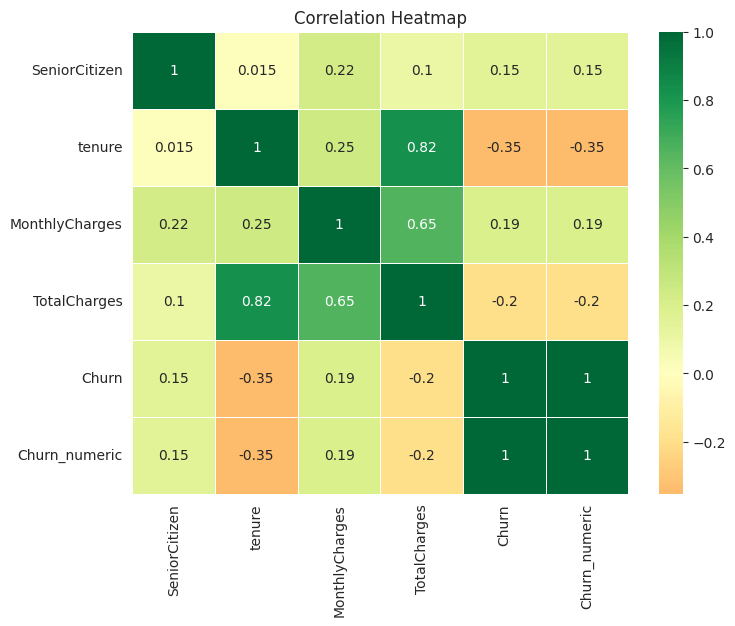

In [38]:
# Select numerical columns only
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,        # show values
    cmap='RdYlGn',     # red = negative, green = positive
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

**Insights**
The Loyalty Anchor **(Tenure vs. Churn)**:
There is a significant negative correlation between tenure and Churn_numeric. This confirms that the longer a customer stays, the less likely they are to leave. Retention efforts should be heavily focused on the early stages of the customer lifecycle.

The Price Sensitivity **(MonthlyCharges vs. Churn)**:
MonthlyCharges shows a positive correlation with Churn. This suggests that customers with higher monthly bills are more prone to leaving, potentially due to price dissatisfaction or better offers from competitors.

The Revenue Accumulation **(Tenure vs. TotalCharges)**:
There is a near-perfect positive correlation (close to 0.8-0.9) between tenure and TotalCharges. While logically obvious, it highlights that long-term retention is the primary driver of high Lifetime Value (LTV).

**Senior Citizen** Risk:
SeniorCitizen status has a slight positive correlation with both MonthlyCharges and Churn. This implies that seniors might be subscribed to more expensive plans/features but are also slightly more likely to churn compared to younger demographics.



# Log Transformation

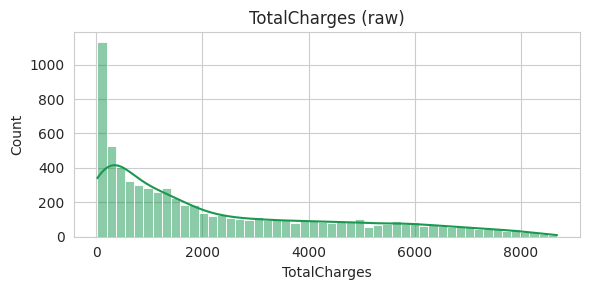

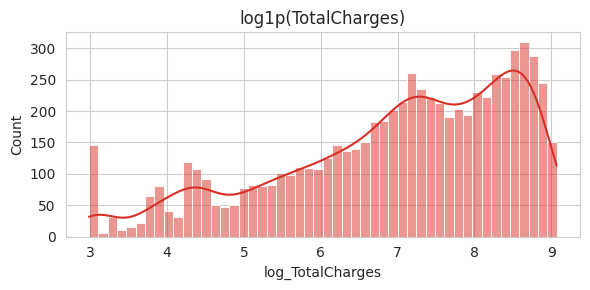

In [39]:
# =========================
# Create log column
# =========================
df['log_TotalCharges'] = np.log1p(df['TotalCharges'])

# =========================
# Plot raw TotalCharges
# =========================
plt.figure(figsize=(6,3))
sns.histplot(df['TotalCharges'], bins=50, kde=True, color='#1a9850')
plt.title("TotalCharges (raw)")
plt.tight_layout()
plt.show()

# =========================
# Plot log TotalCharges
# =========================
plt.figure(figsize=(6,3))
sns.histplot(df['log_TotalCharges'], bins=50, kde=True, color='#d73027')
plt.title("log1p(TotalCharges)")
plt.tight_layout()
plt.show()

# Encoding

In [40]:
cols_to_drop = ['Churn', 'Churn_label', 'tenure_group', 'SeniorCitizen_label', 'TotalCharges']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [41]:
# =========================
#  Keep a copy before encoding
# =========================
df_encoded = df.copy()

# =========================
#  1. Binary Encoding (Yes/No, Male/Female)
# =========================
binary_cols = [
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling'
]

for col in binary_cols:
    # Map Yes/No and Male/Female to 1/0
    df_encoded[col] = df_encoded[col].map({
        'Yes': 1, 'No': 0,
        'Male': 1, 'Female': 0
    })

# =========================
#  2. One-Hot Encoding (Multi-category features)
# =========================
df_encoded = pd.get_dummies(
    df_encoded,
    columns=[
        'Contract',
        'InternetService',
        'PaymentMethod',
        'MultipleLines',
        'PaymentMethod_short'
    ],
    drop_first=True  # avoids dummy variable trap
)

cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_to_fix:
    # Apply the mapping to df_encoded directly
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})
    # Fill any potential NaNs created by map before converting to int
    df_encoded[col] = df_encoded[col].fillna(0).astype(int)

# =========================
#  3. Ensure SeniorCitizen is numeric
# =========================
df_encoded['SeniorCitizen'] = df_encoded['SeniorCitizen'].astype(int)

# =========================
#  Final dataset ready for ML
# =========================
print(df_encoded.head())
print("\nShape after encoding:", df_encoded.shape)

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0            0   
3               1             0                 1            1            0   
4               0             0                 0            0            0   

   StreamingMovies  PaperlessBilling  MonthlyCharges  Churn_numeric  \
0                0         

In [42]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,Churn_numeric,log_TotalCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes,PaymentMethod_short_Credit Card,PaymentMethod_short_Electronic,PaymentMethod_short_Mailed
0,0,0,1,0,1,0,0,1,0,0,0,0,1,29.85,0,3.429137,False,False,False,False,False,True,False,False,False,True,False
1,1,0,0,0,34,1,1,0,1,0,0,0,0,56.95,0,7.544597,True,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,1,0,0,0,0,1,53.85,1,4.692723,False,False,False,False,False,False,True,False,False,False,True
3,1,0,0,0,45,0,1,0,1,1,0,0,0,42.30,0,7.518471,True,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,1,70.70,1,5.028148,False,False,True,False,False,True,False,False,False,True,False


# Heatmap

# Logistic Regression and SVC




✔ Pipeline

Combines preprocessing + model in one flow

✔ Scaling

Essential for Logistic / SVM / Lasso

✔ Cross Validation (5-Fold)

More reliable performance

✔ GridSearchCV

Finds best hyperparameters automatically

✔ Evaluation
Classification → Accuracy, Confusion Matrix
Regression → MSE, R²

In [44]:
# =========================
#  Import Libraries
# =========================
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

# Cross Validation

In [45]:
# 5-Fold Cross Validation (splits data into 5 parts)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# LOGISTIC REGRESSION PIPELINE + GRID SEARCH

In [47]:
# Create pipeline (Scaling + Model)
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

# Hyperparameter grid
log_params = {
    "model__C": np.logspace(-3, 3, 7),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

# Grid Search with CV
log_grid = GridSearchCV(log_pipe, log_params, cv=kf)
log_grid.fit(X_train, y_train)

# Predictions
log_pred = log_grid.predict(X_test)

# Evaluation
log_acc = accuracy_score(y_test, log_pred)

In [48]:
# Create pipeline (Scaling is VERY important for SVM)
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

# Hyperparameter grid
svm_params = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

# Grid Search with CV
svm_grid = GridSearchCV(svm_pipe, svm_params, cv=kf)
svm_grid.fit(X_train, y_train)

# Predictions
svm_pred = svm_grid.predict(X_test)

# Evaluation
svm_acc = accuracy_score(y_test, svm_pred)

# CONFUSION MATRIX (LOGISTIC)

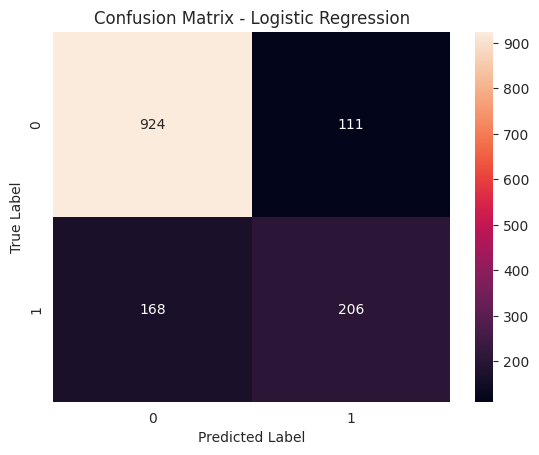

In [55]:
# =========================
#  Confusion Matrix WITH numbers
# =========================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")  # annot=True shows numbers

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# CONFUSION MATRIX (SVM)

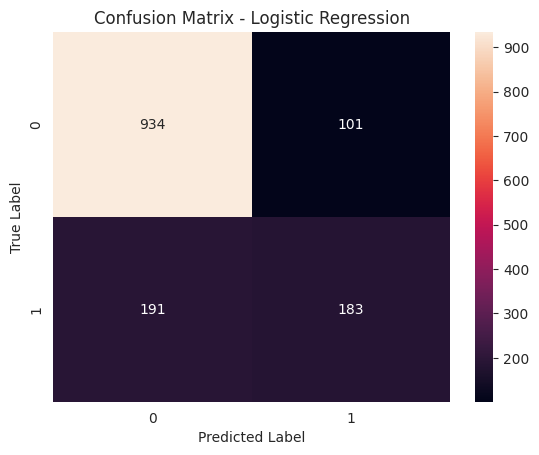

In [58]:
# =========================
#  Confusion Matrix WITH numbers
# =========================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")  # annot=True shows numbers

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# PRINT BEST RESULTS

In [59]:
print(" Logistic Best Params:", log_grid.best_params_)
print(" Logistic Accuracy:", log_acc)

print(" SVM Best Params:", svm_grid.best_params_)
print(" SVM Accuracy:", svm_acc)



 Logistic Best Params: {'model__C': np.float64(100.0), 'model__penalty': 'l1', 'model__solver': 'liblinear'}
 Logistic Accuracy: 0.8019872249822569
 SVM Best Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
 SVM Accuracy: 0.7927608232789212


# MODEL COMPARISON

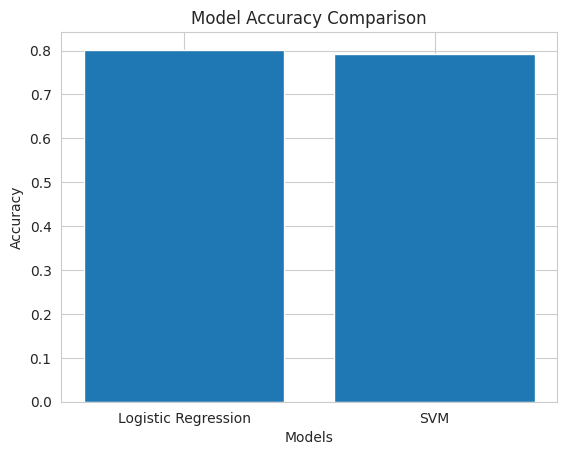

In [60]:
models = ["Logistic Regression", "SVM"]
scores = [log_acc, svm_acc]

plt.figure()
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

In [53]:
# =========================
#  Create Metrics Table
# =========================
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic metrics
log_metrics = [
    accuracy_score(y_test, log_pred),
    precision_score(y_test, log_pred),
    recall_score(y_test, log_pred),
    f1_score(y_test, log_pred)
]

# SVM metrics
svm_metrics = [
    accuracy_score(y_test, svm_pred),
    precision_score(y_test, svm_pred),
    recall_score(y_test, svm_pred),
    f1_score(y_test, svm_pred)
]

# Create DataFrame
metrics_df = pd.DataFrame(
    [log_metrics, svm_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1 Score"],
    index=["Logistic", "SVM"]
)

print(metrics_df)

          Accuracy  Precision    Recall  F1 Score
Logistic  0.801987   0.649842  0.550802  0.596237
SVM       0.792761   0.644366  0.489305  0.556231


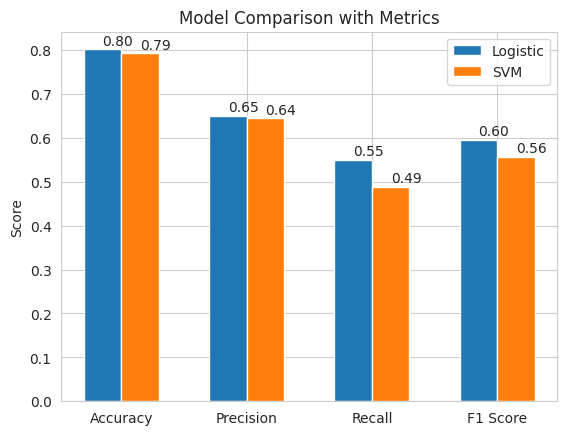

In [54]:
# =========================
#  Bar Plot with Values
# =========================
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics))

plt.figure()

# Plot for each model
plt.bar(x - 0.15, log_metrics, width=0.3, label="Logistic")
plt.bar(x + 0.15, svm_metrics, width=0.3, label="SVM")

# Add numbers on top
for i, v in enumerate(log_metrics):
    plt.text(i - 0.15, v + 0.01, f"{v:.2f}")

for i, v in enumerate(svm_metrics):
    plt.text(i + 0.15, v + 0.01, f"{v:.2f}")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison with Metrics")
plt.legend()

plt.show()